Found 5 classes: ['Sango', 'Djambala', 'Tilla', 'Bibi', 'MPenzi']
Using a 3x2 grid.


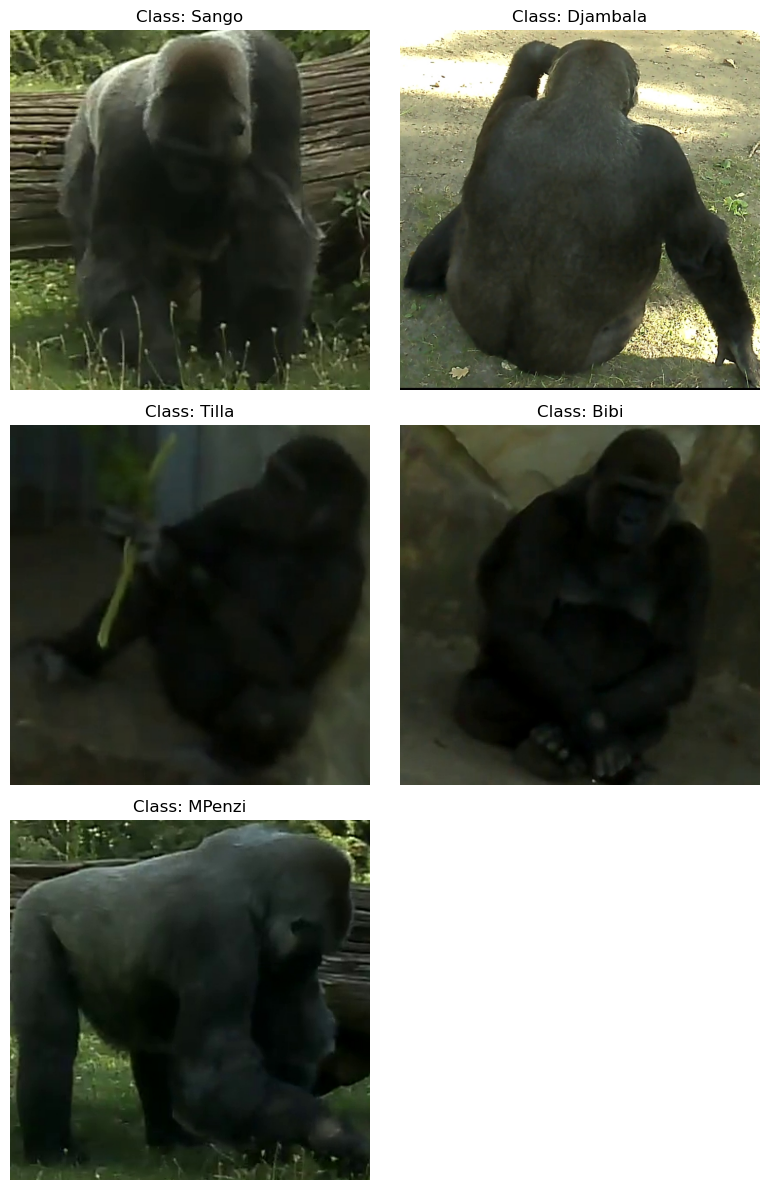

In [12]:
import os
from typing import Callable
import matplotlib.pyplot as plt
from PIL import Image
import random
import shutil
random.seed(42) # For reproducibility
# Your initial setup
data_dir = "/workspaces/vast-gorilla/gorillawatch/data/berlin_zoo_dataset/squared_renamed/body"
label_extractor: Callable[[str], str] = lambda f: f.split('_')[0]
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".png")]

#shuffle files to get random examples

random.shuffle(files)

# 1. Group files by class and select one example per class
class_examples = {}
for f in files:
    label = label_extractor(os.path.basename(f))
    if label not in class_examples:
        class_examples[label] = f # Store the first file found for this class

classes = list(class_examples.keys())
num_classes = len(classes)
print(f"Found {num_classes} classes: {classes}")

# 2. Determine subplot grid size
# A square or near-square layout works best
cols = int(num_classes**0.5)
rows = (num_classes + cols - 1) // cols # Ceiling division
print(f"Using a {rows}x{cols} grid.")

# Set up inline plotting for Jupyter

# 3. Create the figure and a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() # Flatten the axes array for easy iteration

# 4. Display images
for i, (label, filepath) in enumerate(class_examples.items()):
    # Load the image using PIL
    img = Image.open(filepath)

    copy_dir = "/sc/home/iven.schlegelmilch/bachelor_thesis_code/zoo_images"
    # copy each filepath to copydir
    shutil.copy(filepath, os.path.join(copy_dir, os.path.basename(filepath)))

    # Get the specific axis for this image
    ax = axes[i]

    # Display the image
    ax.imshow(img)
    ax.set_title(f"Class: {label}")
    ax.axis('off') # Hide axes ticks and labels for cleaner image display

# Hide any unused subplots
for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()
# Show the plot
plt.show()